# Descent and Globalization

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 4 rewritten and 1 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Define Test Function and Derivatives

Let's get started by defining a test function we will use throughout the notebook.

Consider a scalar function $f(x): \mathbb{R} \rightarrow \mathbb{R}$ to allow for easier visualization. Let

$$f(x) = 0.5 (x-1)^4 + (x+1)^3 - 10 x^2 + 5 x$$

$$f'(x) = 6 - 8 x - 3 x^2 + 2 x^3$$

$$f''(x) = -8 - 6 x + 6 x^2 $$

In [2]:
## Define f(x)
f = lambda x: 0.5 * (x - 1) ** 4 + (x + 1) ** 3 - 10 * x**2 + 5 * x

## Define f'(x)
df = lambda x: 6 - 8 * x - 3 * x**2 + 2 * x**3

## Define f''(x)
ddf = lambda x: -8 - 6 * x + 6 * x**2

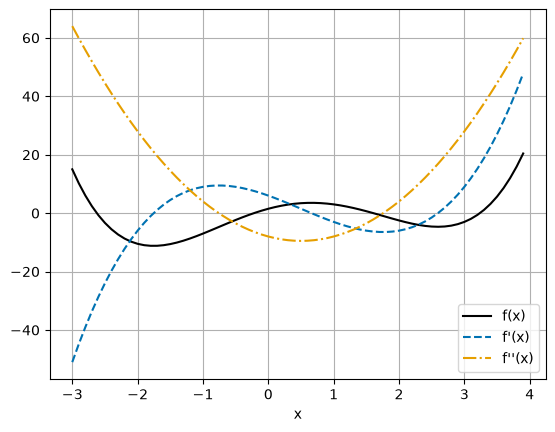

In [3]:
plt.figure()
xplt = np.arange(-3, 4, 0.1)

fplt = f(xplt)
dfplt = df(xplt)
ddfplt = ddf(xplt)

# House cycle in order (figures/dowling.mplstyle): black solid, blue dashed,
# orange dash-dot. These were matplotlib's "b"/"r"/"g", which are outside the
# Okabe-Ito palette the rest of the notebook now uses.
plt.plot(xplt, fplt, label="f(x)", color="black", linestyle="-")
plt.plot(xplt, dfplt, label="f'(x)", color="#0072B2", linestyle="--")
plt.plot(xplt, ddfplt, label="f''(x)", color="#E69F00", linestyle="-.")
plt.xlabel("x")
plt.legend()
plt.grid()
plt.show()

## Geometric Insights into Newton Steps

### Motivation

We can interpret Newton-type methods for unconstrained optimization as root finding of $\nabla f(x) = 0$.

At iteration $k$, we assemble an approximation to $f(x)$ using a Taylor series expansion:

$$f(x^k + p^k) \approx f(x^k) + \nabla f(x^k)^T p^k + \frac{1}{2} (p^k)^T (B^k) p^k$$

and solve for $p^k$ such that $\nabla f(x^k + p^k)=0$. This gives:

$$p^k = -(B^k)^{-1} \nabla f(x^k)$$

The choice of $B^k$ determines the algorithm classification:
* Pure **Newton Method**, $B^k = \nabla^2 f(x^k)$
* **Steepest Descent**, $B^k = \frac{1}{\alpha} I$, where scalar $\alpha$ is sometimes known as the dampening factor
* **Levenberg-Marquardt**, $B^k = \nabla^2 f(x^k) + \delta I$, where scalar $\delta$ is chosen to ensure $B^k$ is positive definite.
* **Broyden Methods**, $B^{k}$ is approximated using history of gradient evaluations, i.e., $\nabla f(x^0), ... \nabla f(x^k)$. We will study the SR1 and BFGS formulas in this family of methods.

This section **explores how choosing $B^k$ impacts the shape of the approximation and calculated step.**

### Compute and Plot Steps

Define a function that:
* Computes the i. Newton, ii. Levenberg-Marquardt and iii. Steepest Descent Step for a given starting point $x_0$
* Plots the step in terms of $f(x)$ and $f'(x)$

In [4]:
def calc_step(x0, epsLM):

    # Evaluate f(x0), f'(x0) and f''(x0)
    f0 = f(x0)
    df0 = df(x0)
    ddf0 = ddf(x0)
    print("x0 = ", x0)
    print("f(x0) =", f0)
    print("f'(x0) =", df0)
    print("f''(x0) =", ddf0)

    ### Calculate steps

    # Newton Step
    xN = x0 - df0 / ddf0

    print("\n### Newton Step ###")
    print("xN = ", xN)
    print("pN = xN - x0 = ", xN - x0)
    f_xN = f(xN)
    print("f(xN) = ", f_xN)
    print("f(xN) - f(x0) = ", f_xN - f0)

    # Levenberg-Marquardt Step
    # Recall the eigenvalue of a 1x1 matrix is just that value
    dffLM = np.amax([ddf0, epsLM])
    xLM = x0 - df0 / dffLM

    print("\n### Levenberg-Marquardt Step ###")
    print("xLM = ", xLM)
    print("pLM = xLM - x0 = ", xLM - x0)
    f_xLM = f(xLM)
    print("f(xLM) = ", f_xLM)
    print("f(xLM) - f(x0) = ", f_xLM - f0)

    # Steepest Descent Step
    xSD = x0 - df0 / 1

    print("\n### Steepest Descent Step ###")
    print("xSD = ", xSD)
    print("pSD = xSD - x0 = ", xSD - x0)
    f_xSD = f(xSD)
    print("f(xSD) = ", f_xSD)
    print("f(xSD) - f(x0) = ", f_xSD - f0)

    ### Plot Surrogates on x vs f(x)

    ### Plot f(x)
    # Okabe-Ito colours paired with distinct linestyles and markers, in the
    # order used by figures/dowling.mplstyle: black solid, blue dashed, orange
    # dash-dot, bluish green dotted. All three surrogates used to be dashed and
    # were told apart by colour alone, which does not survive a photocopy.
    plt.figure()
    plt.scatter(x0, f0, label="$x_0$", color="black", zorder=5)
    plt.plot(xplt, fplt, label="f(x)", color="black", linestyle="-")

    ### Plot approximation for Newton's method
    fN = lambda x: f0 + df0 * (x - x0) + 0.5 * ddf0 * (x - x0) ** 2
    plt.plot(xplt, fN(xplt), label="Newton", linestyle="--", color="#0072B2")
    plt.scatter(xN, f(xN), color="#0072B2", marker="x")

    ### Plot approximation for LM
    fLM = lambda x: f0 + df0 * (x - x0) + 0.5 * dffLM * (x - x0) ** 2
    plt.plot(xplt, fLM(xplt), label="LM", linestyle="-.", color="#E69F00")
    plt.scatter(xLM, f(xLM), color="#E69F00", marker="s")

    ### Plot approximation for SD
    fSD = lambda x: f0 + df0 * (x - x0) + 0.5 * (x - x0) ** 2
    plt.plot(xplt, fSD(xplt), label="Steepest", linestyle=":", color="#009E73")
    plt.scatter(xSD, f(xSD), color="#009E73", marker="^")

    # plt.plot([x0, xLM],[f0, f(xLM)],label="LM",color="green",marker="o")
    # plt.plot([x0,xSD],[f0,f(xSD)],label="Steepest",color="blue",marker="s")

    plt.xlim((-3.5, 4.5))
    plt.ylim((-12.5, 22.5))
    plt.xlabel("$x$")
    plt.ylabel("$f(x)$")
    plt.legend()
    plt.title("Function and Surrogates")
    plt.grid()
    plt.show()

    ### Plot Surrogates on x vs f'(x)
    plt.figure()
    plt.scatter(x0, df0, label="$x_0$", color="black", zorder=5)
    plt.plot(xplt, dfplt, label="f'(x)", color="black", linestyle="-")

    ### Plot approximation for Newton's method
    dfN = lambda x: df0 + ddf0 * (x - x0)
    plt.plot(xplt, dfN(xplt), label="Newton", linestyle="--", color="#0072B2")
    plt.scatter(xN, df(xN), color="#0072B2", marker="x")

    ### Plot approximation for LM
    dfLM = lambda x: df0 + dffLM * (x - x0)
    plt.plot(xplt, dfLM(xplt), label="LM", linestyle="-.", color="#E69F00")
    plt.scatter(xLM, df(xLM), color="#E69F00", marker="s")

    ### Plot approximation for SD
    dfSD = lambda x: df0 + (x - x0)
    plt.plot(xplt, dfSD(xplt), label="Steepest", linestyle=":", color="#009E73")
    plt.scatter(xSD, df(xSD), color="#009E73", marker="^")

    plt.xlim((-3.5, 4.5))
    plt.ylim((-50, 50))
    plt.xlabel("$x$")
    plt.ylabel("$f'(x)$")
    plt.legend()
    plt.title("First Derivative and Surrogates")
    plt.grid()
    plt.show()

### Consider $x_0 = -3$

x0 =  -3
f(x0) = 15.0
f'(x0) = -51
f''(x0) = 64

### Newton Step ###
xN =  -2.203125
pN = xN - x0 =  0.796875
f(xN) =  -8.660857647657394
f(xN) - f(x0) =  -23.660857647657394

### Levenberg-Marquardt Step ###
xLM =  -2.203125
pLM = xLM - x0 =  0.796875
f(xLM) =  -8.660857647657394
f(xLM) - f(x0) =  -23.660857647657394

### Steepest Descent Step ###
xSD =  48.0
pSD = xSD - x0 =  51.0
f(xSD) =  2534689.5
f(xSD) - f(x0) =  2534674.5


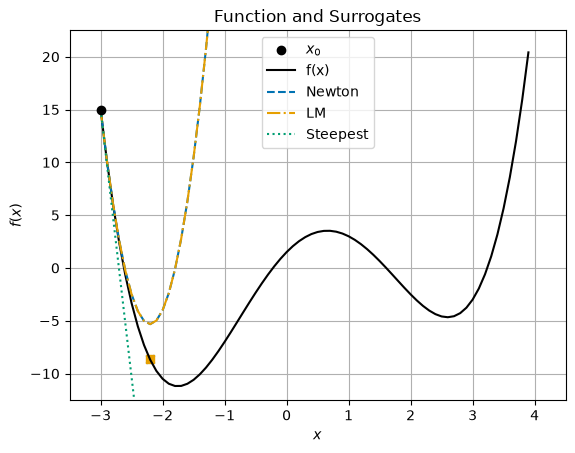

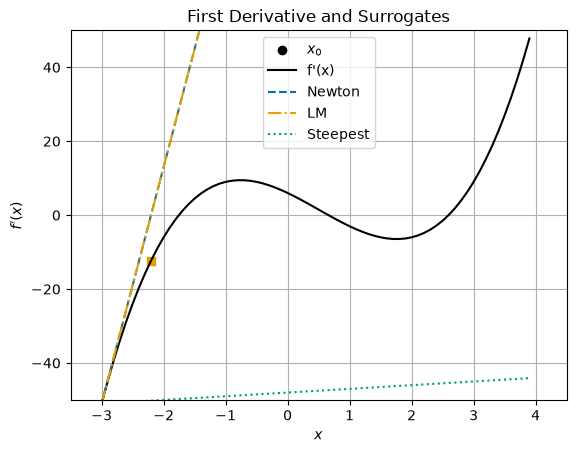

In [5]:
calc_step(-3, 1e-2)

**Discussion**
* In this case, do we expect the Newton and LM steps to be the same? Explain.
* Why does $f(x)$ increase with a steepest descent ($B^k = I$) step? I thought the main idea was that because $B^k$ is **positive definite** the step is in a **descent direction**!

### Consider $x_0 = 0$

x0 =  0
f(x0) = 1.5
f'(x0) = 6
f''(x0) = -8

### Newton Step ###
xN =  0.75
pN = xN - x0 =  0.75
f(xN) =  3.486328125
f(xN) - f(x0) =  1.986328125

### Levenberg-Marquardt Step ###
xLM =  -600.0
pLM = xLM - x0 =  -600.0
f(xLM) =  65014556401.5
f(xLM) - f(x0) =  65014556400.0

### Steepest Descent Step ###
xSD =  -6.0
pSD = xSD - x0 =  -6.0
f(xSD) =  685.5
f(xSD) - f(x0) =  684.0


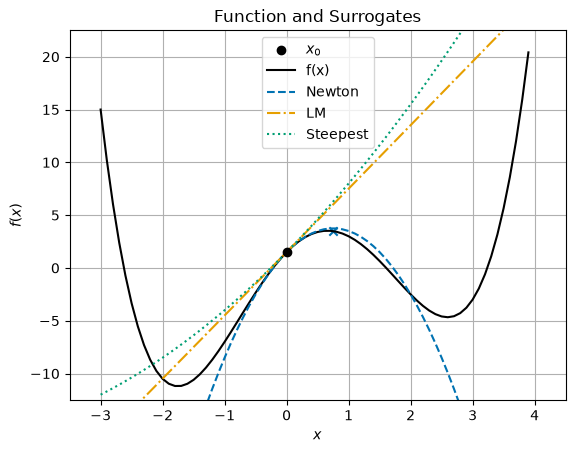

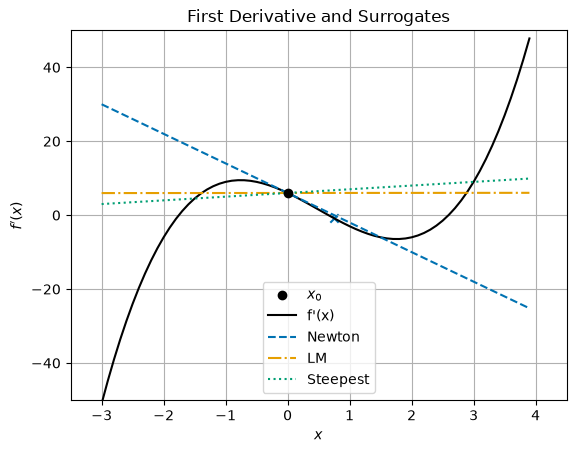

In [6]:
calc_step(0, 1e-2)

**Discussion**
* Why does $f(x)$ increase for all of the steps?
* Explain Newton-type method in the context of root finding for $\nabla f(x) = 0$ using the second plot.

### Descent Properties

For $p^k=-(B^k)^{-1}\nabla f(x^k)$, positive definiteness of $B^k$ gives

$$\nabla f(x^k)^T p^k=-\nabla f(x^k)^T(B^k)^{-1}\nabla f(x^k)<0.$$

Thus $p^k$ is a descent direction whenever $\nabla f(x^k)\ne0$. A line search still chooses a step length that produces sufficient decrease. (Biegler, Eqs. 3.2--3.5, p. 41.)

## Line Search

Excerpts from **Section 3.4** in Biegler (2010).

The **Wolfe conditions** require that (3.31) be satisfied as well as

  \begin{align}
  \nabla f(x^k + \alpha^k p^k)^T p^k &\geq \zeta \nabla f(x^k)^T p^k \tag{3.32}
  \end{align}

  for $\zeta \in (\eta, 1)$. From Figure 3.2, we see that $\alpha \in [\alpha_w, \alpha_a]$ satisfies these conditions.

The **strong Wolfe conditions** are more restrictive and require satisfaction of

  \begin{align}
  |\nabla f(x^k + \alpha^k p^k)^T p^k| &\leq \zeta |\nabla f(x^k)^T p^k| \tag{3.33}
  \end{align}

  for $\zeta \in (\eta, 1)$. From Figure 3.2, we see that $\alpha \in [\alpha_w, \alpha_{sw}]$ satisfies these conditions.

The **Goldstein** or **Goldstein–Armijo conditions** require that (3.31) be satisfied as well as

  \begin{align}
  f(x^k + \alpha^k p^k) &\geq f(x^k) + (1 - \eta) \alpha^k \nabla f(x^k)^T p^k \tag{3.34}
  \end{align}

The generated figure below shows these acceptance intervals for the notebook's test function.

### Global convergence result

Under the standard smoothness and bounded-level-set assumptions, a Goldstein--Armijo line search satisfies the Zoutendijk condition

$$\sum_{k=0}^{\infty}\cos^2(\theta^k)\,\|\nabla f(x^k)\|^2<\infty,$$

where $\theta^k$ is the angle between $p^k$ and $-\nabla f(x^k)$. If those angles stay bounded away from $90^\circ$, the gradient norm tends to zero. (Biegler, Theorem 3.3, pp. 48--49; Nocedal and Wright, Theorem 3.2, p. 38.)

### Backtracking line search

1. Compute a descent direction $p^k$ and start with $\alpha=1$.
2. While the Armijo condition fails, reduce $\alpha\leftarrow\rho\alpha$ for $0<\rho<1$.
3. Accept $\alpha^k=\alpha$ and set $x^{k+1}=x^k+\alpha^k p^k$.

When $\alpha<1$, also guard against a step that is unnecessarily short, for example with a Wolfe or Goldstein condition. (Biegler, Algorithm 3.2, p. 50.)

### Recovery of the fast local rate

If the iterates converge to a strict local minimizer and the Hessian approximations satisfy the Dennis--Moré condition

$$\frac{\|(B^k-\nabla^2 f(x^k))p^k\|}{\|p^k\|}\to0,$$

then the full step $\alpha^k=1$ is eventually accepted and convergence is superlinear. (Biegler, Theorem 3.4, p. 50.)

### Visualization Code

### The line search conditions, as one picture

![Armijo and Goldstein conditions for steepest descent from $x^k=-3$: the accepted step lengths are the interval $[\alpha_g, \alpha_a]$ where the function value stays below the Armijo line and above the Goldstein line.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/line-search-conditions.png)

This is Biegler Figure 3.2 for our test function. It is rendered from
`figures/plots/line-search-conditions.py` and is the **same image printed in the course
pack**, so what you annotate in lecture and what you see here cannot drift apart.

The cells below are the live version: `plot_alpha` redraws this for any $x^k$, any
algorithm and any $\alpha_{\max}$, so you can explore cases the static figure does not
cover -- including one where the line search fails.


**Goal**: Visualize Armijo and Goldstein conditions for an example.

In [7]:
def plot_alpha(xk, eta_ls=0.25, algorithm="newton", alpha_max=1.0):
    """
    Calculate step and visualize line search conditions

    Arguments:
        xk : initial point (required)
        eta_ls : eta in Goldstein-Armijo conditions
        algorithm : either "newton" or "steepest-descent"
        alpha_max : plots alpha between 0 and alpha_max

    Returns:
        Nothing

    Creates:
        Plot showing function value and line search conditions as a function of alpha
    """

    fxk = f(xk)
    dfxk = df(xk)

    if algorithm == "newton":
        pk = -dfxk / ddf(xk)
    elif algorithm == "steepest-descent":
        pk = -dfxk
    else:
        raise ValueError(
            "algorithm argument must be either 'newton' or 'steepest-descent'"
        )

    print("Considering xk =", xk, "and f(xk) = ", fxk)
    print("Step with", algorithm, "algorithm:")
    print("pk = ", pk)
    print("With full step, xk+1 =", pk + xk, "and f(xk+1) =", f(xk + pk))

    n = 100
    alpha = np.linspace(0, alpha_max, n)
    fval = np.zeros(n)

    for i in range(0, n):
        fval[i] = f(xk + alpha[i] * pk)

    fs = 18
    plt.figure()

    # Evaluate f(x^{k+1}) for different alpha values.
    # Colour and linestyle match figures/plots/line-search-conditions.py, the
    # static version of this figure in the course pack: house cycle in order,
    # black solid, blue dashed, orange dash-dot. The linestyles are what make
    # the three series separable in greyscale.
    plt.plot(alpha, fval, color="black", linestyle="-", label=r"$f(x^{k+1})$")

    # Armijo condition
    arm = np.zeros(n)
    for i in range(0, n):
        arm[i] = fxk + eta_ls * alpha[i] * dfxk * pk

    plt.plot(alpha, arm, color="#0072B2", linestyle="--", label="Armijo")

    # Goldstein condition
    gold = np.zeros(n)
    for i in range(0, n):
        gold[i] = fxk + (1 - eta_ls) * alpha[i] * dfxk * pk

    plt.plot(alpha, gold, color="#E69F00", linestyle="-.", label="Goldstein")

    # Apply backtracking linestep (starting with alpha = alpha_max)
    i = n - 1
    flag = True
    failed = False
    while flag:

        if i < n - 1 and fval[i] < gold[i]:
            flag = False
            print(
                "Line search failed. Goldstein conditions violated. Consider increasing alpha_max."
            )
            failed = True

        # Armijo condition
        if fval[i] < arm[i]:
            flag = False
        else:
            i = i - 1

        if i < 0:
            print("Line search failed. Try decreasing alpha_max.")
            failed = True
            # Stop here. Without this, the loop keeps going with a negative
            # index, which wraps around to the end of the array and reports a
            # second, contradictory diagnosis.
            flag = False

    if not failed:
        print(
            "alphak =",
            alpha[i],
            "with backtracking line search starting at alpha =",
            alpha_max,
        )
        print("f(xk + alphak*pk) =", fval[i])

        plt.scatter(
            alpha[i],
            fval[i],
            marker="x",
            color="black",
            label=r"$\alpha^{k}$ for line search",
        )

    # Labels
    plt.xlabel(r"$\alpha^k$", fontsize=fs)
    plt.ylabel(r"$f(x^k + \alpha^k p^k)$", fontsize=fs)
    plt.grid()
    plt.legend()
    plt.show()

### Newton Step, $x^k = -3$

Considering xk = -3 and f(xk) =  15.0
Step with newton algorithm:
pk =  0.796875
With full step, xk+1 = -2.203125 and f(xk+1) = -8.660857647657394
alphak = 1.5 with backtracking line search starting at alpha = 1.5
f(xk + alphak*pk) = -11.1743426900357


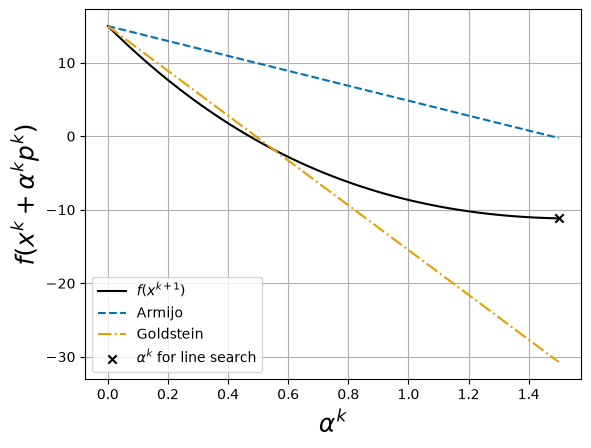

In [8]:
plot_alpha(-3, eta_ls=0.25, algorithm="newton", alpha_max=1.5)

**Discussion**
* Why did the backtracking line search stop at $\alpha^k = $ `alpha_max`?
* Is it possible to find a larger improvement in $f(x)$ with $\alpha^k > 1$?

### Steepest Descent Step, $x^k = -3$

Considering xk = -3 and f(xk) =  15.0
Step with steepest-descent algorithm:
pk =  51
With full step, xk+1 = 48 and f(xk+1) = 2534689.5
alphak = 0.03535353535353535 with backtracking line search starting at alpha = 0.1
f(xk + alphak*pk) = -8.67145500733185


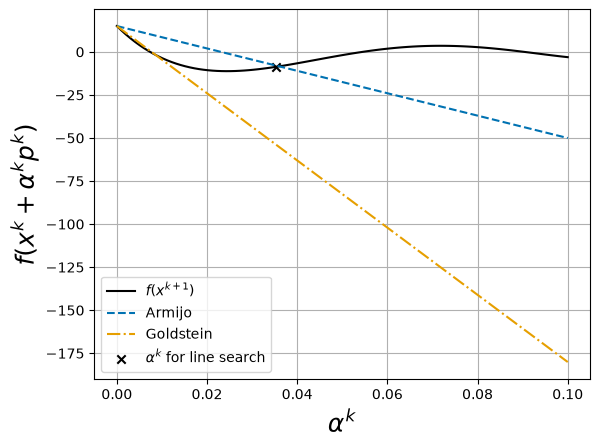

In [9]:
plot_alpha(-3, eta_ls=0.25, algorithm="steepest-descent", alpha_max=1e-1)

**Discussion**
* Why did the line search stop where the Armijo conditions are satisfied?
* Why not further decrease $\alpha^k$ to achieve a greater improvement in the objective?

### Newton Step, $x^k = 0$

Considering xk = 0 and f(xk) =  1.5
Step with newton algorithm:
pk =  0.75
With full step, xk+1 = 0.75 and f(xk+1) = 3.486328125
Line search failed. Goldstein conditions violated. Consider increasing alpha_max.


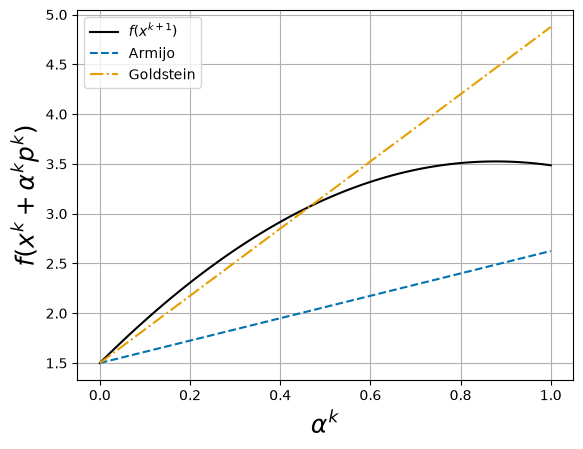

In [10]:
plot_alpha(0, eta_ls=0.25, algorithm="newton", alpha_max=1.0)

**Discussion**
* Why does the line search fail?
* How could we modify Newton's method to improve robustness?

### Steepest Descent Step, $x^k = 0$

Considering xk = 0 and f(xk) =  1.5
Step with steepest-descent algorithm:
pk =  -6
With full step, xk+1 = -6 and f(xk+1) = 685.5
alphak = 0.4191919191919192 with backtracking line search starting at alpha = 0.5
f(xk + alphak*pk) = -2.9749848430038526


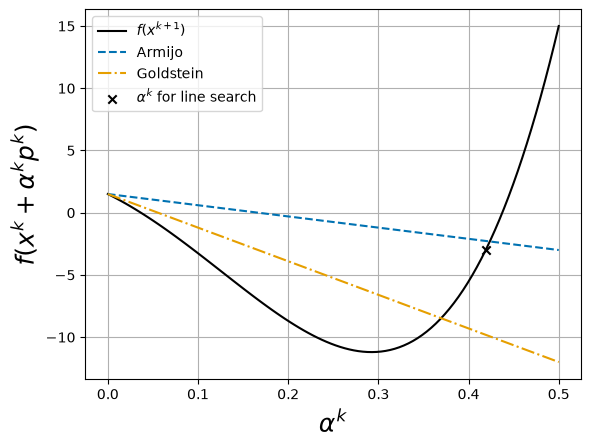

In [11]:
plot_alpha(0, eta_ls=0.25, algorithm="steepest-descent", alpha_max=5e-1)

**Discussion**
* How does the region where the Armijo and Goldstein conditions are satisfied change for different values of `eta_ls`?

## Trust Regions

Excerpts from **Section 3.5** in Biegler (2010).

### Main Idea and General Algorithm

At iteration $k$, minimize a local quadratic model only where it is trusted:

$$\min_p\;m^k(p)=\nabla f(x^k)^Tp+\tfrac12p^TB^kp\qquad\text{s.t.}\qquad\|p\|\le\Delta^k.$$

The radius $\Delta^k$ is updated by comparing the objective's actual reduction with the model's predicted reduction. (Biegler, Eq. 3.49, p. 53.)

For each iteration:

1. Solve the trust region subproblem for $p^k$.
2. Compute $\rho^k=\text{actual reduction}/\text{predicted reduction}$.
3. Shrink $\Delta^k$ when the model predicts poorly; expand it after a good boundary step; otherwise retain it.
4. Accept $x^k+p^k$ only when $\rho^k$ exceeds the acceptance threshold.

This separates *step computation* from *step acceptance*. (Biegler, Algorithm 3.3, p. 53.)

### Trust Region Variations

![Levenberg--Marquardt arcs and the Powell dogleg path for several trust region radii.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/trust-region-steps.png)

The Levenberg--Marquardt path varies a multiplier continuously; dogleg uses straight segments connecting the origin, Cauchy step, and Newton step.

$p^C$: Cauchy step
    
$p^N$: Newton step

#### Levenberg-Marquardt

A feasible step $p^k$ solves the trust region subproblem if and only if some $\delta\ge0$ satisfies

$$ (B^k+\delta I)p^k=-\nabla f(x^k),\qquad\delta(\Delta^k-\|p^k\|)=0,\qquad B^k+\delta I\succeq0.$$

The explicit feasibility condition $\|p^k\|\le\Delta^k$ is essential; it is omitted from Biegler's printed Theorem 3.6 but included in Nocedal and Wright, Theorem 4.1, p. 70. As $\delta$ grows, the step rotates toward steepest descent and decreases in length.

#### Powell Dogleg

The Cauchy step minimizes the quadratic model along $-\nabla f(x^k)$, truncated at the trust region boundary. For positive curvature along the gradient,

$$p^C=-\frac{\nabla f(x^k)^T\nabla f(x^k)}{\nabla f(x^k)^TB^k\nabla f(x^k)}\nabla f(x^k);$$

otherwise use the boundary step $p^C=-\Delta^k\nabla f(x^k)/\|\nabla f(x^k)\|$. (Biegler, Eq. 3.52, p. 54.)

For positive-definite $B^k$, the dogleg step follows three cases:

- take the Newton step when $\|p^N\|\le\Delta^k$;
- truncate the Cauchy direction when $\Delta^k\le\|p^C\|$;
- otherwise choose the point on the segment from $p^C$ to $p^N$ whose norm is $\Delta^k$.

Dogleg is inexpensive but generally approximates, rather than exactly solves, the trust region subproblem.